In [21]:
import os
import zipfile
from pathlib import Path
import random
import shutil
import math
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import transforms, models, datasets

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

from tqdm.notebook import tqdm

cwd = Path.cwd()
if (cwd / 'intel-image-classification').exists():
    DATA_DIR = (cwd / 'intel-image-classification').resolve()
elif (cwd.parent / 'intel-image-classification').exists():
    DATA_DIR = (cwd.parent / 'intel-image-classification').resolve()
else:
    DATA_DIR = Path('../intel-image-classification').resolve()  # fallback

print("DATA_DIR:", DATA_DIR)
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

device = torch.device("cpu")


DATA_DIR: /Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/intel-image-classification


In [22]:
train_dir = DATA_DIR / 'seg_train/seg_train/'
test_dir  = DATA_DIR / 'seg_test/seg_test/'
pred_dir  = DATA_DIR / 'seg_pred/seg_pred/'

print("Using paths:")
print("  train_dir:", train_dir)
print("  test_dir: ", test_dir)
print("  pred_dir: ", pred_dir)

def build_df_from_imagefolder(root_dir):
    rows = []
    for class_dir in sorted([d for d in root_dir.iterdir() if d.is_dir()]):
        cls_name = class_dir.name
        for img in class_dir.glob("*"):
            if img.is_file():
                rows.append({"path": str(img), "label": None, "class": cls_name})
    df = pd.DataFrame(rows)
    classes = sorted(df['class'].unique())
    cls2idx = {c:i for i,c in enumerate(classes)}
    if not df.empty:
        df['label'] = df['class'].map(cls2idx)
    return df, classes, cls2idx

train_df, train_classes, train_cls2idx = build_df_from_imagefolder(train_dir)
test_df, test_classes, test_cls2idx = build_df_from_imagefolder(test_dir)

if test_df is not None and len(test_df)>0 and (not test_classes or len(test_classes)==0):
    test_classes = train_classes
    test_cls2idx = train_cls2idx

print("Train classes:", train_classes)
print("Train samples:", len(train_df) if isinstance(train_df, pd.DataFrame) else 0)
print("Test samples:", len(test_df) if isinstance(test_df, pd.DataFrame) else 0)

CLASS_NAMES = train_classes
NUM_CLASSES = len(CLASS_NAMES)
print("NUM_CLASSES =", NUM_CLASSES)


Using paths:
  train_dir: /Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/intel-image-classification/seg_train/seg_train
  test_dir:  /Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/intel-image-classification/seg_test/seg_test
  pred_dir:  /Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/intel-image-classification/seg_pred/seg_pred
Train classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train samples: 14034
Test samples: 3000
NUM_CLASSES = 6


This is a multi-class image classification problem with 6 classes


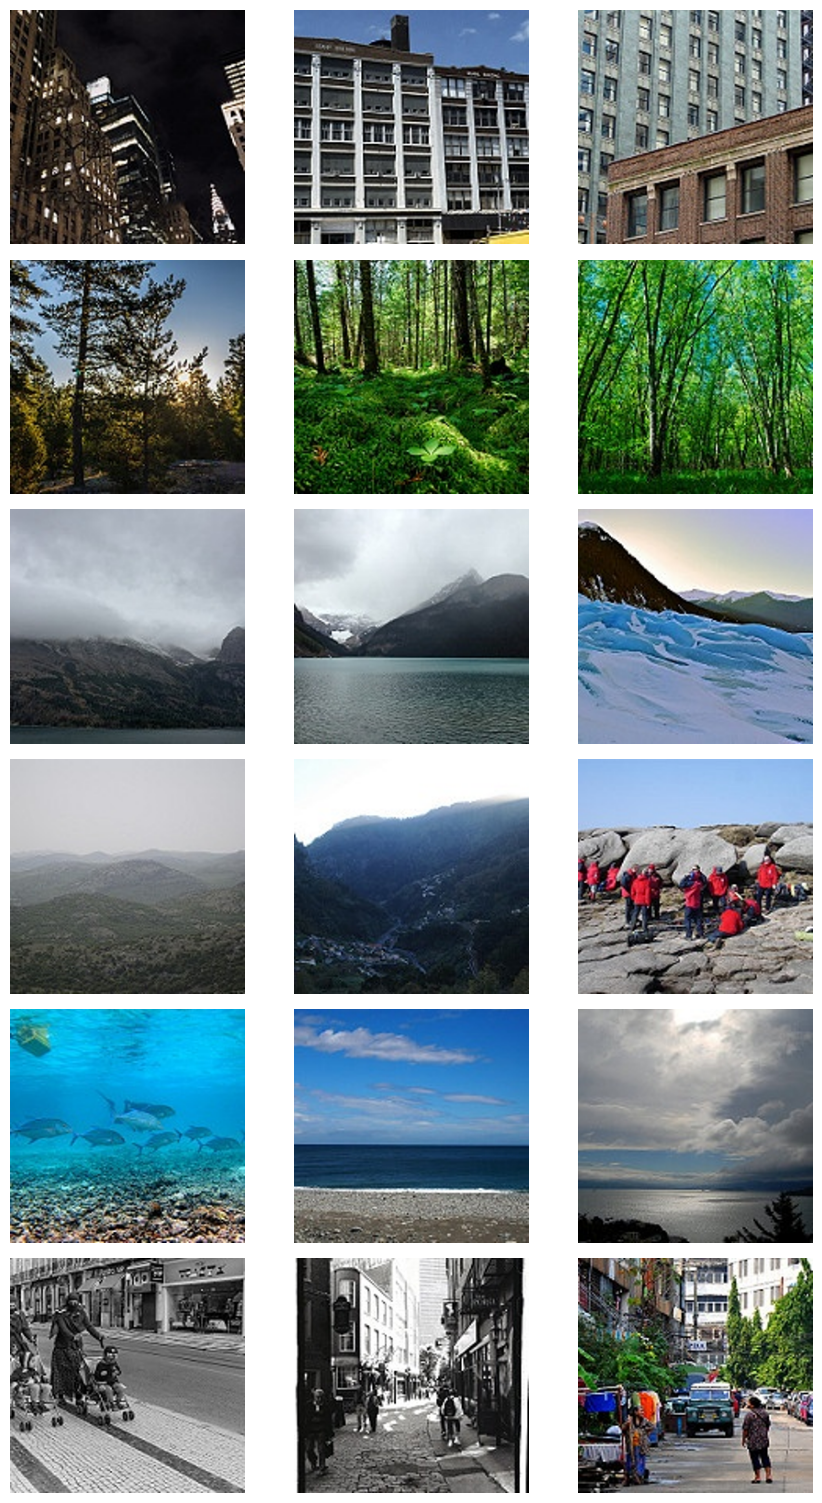

In [23]:
print(f"This is a multi-class image classification problem with {NUM_CLASSES} classes")

n_examples = 3
fig_cols = n_examples
fig_rows = len(CLASS_NAMES)
plt.figure(figsize=(fig_cols*3, fig_rows*2.6))

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = train_dir / cls
    if not cls_dir.exists():
        # fallback: find first path in df for that class
        sample_paths = train_df[train_df['class']==cls]['path'].tolist()[:n_examples]
    else:
        imgs = [p for p in cls_dir.glob("*") if p.is_file()]
        sample_paths = [str(p) for p in imgs[:n_examples]]
    for j in range(n_examples):
        idx = i * n_examples + j + 1
        plt.subplot(fig_rows, fig_cols, idx)
        if j < len(sample_paths):
            im = Image.open(sample_paths[j]).convert("RGB")
            plt.imshow(im.resize((256,256)))
            plt.axis('off')
            if j == 0:
                plt.ylabel(cls, fontsize=12)
        else:
            plt.text(0.5, 0.5, "No image", ha='center', va='center')
            plt.axis('off')

plt.tight_layout(rect=[0,0,1,0.97])


In [26]:
def check_images(df, verbose=False, report_every=100):
    broken = []
    if df is None or not isinstance(df, pd.DataFrame) or len(df) == 0:
        return broken
    paths = df['path'].tolist()
    total = len(paths)
    for i, p in enumerate(paths, 1):
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception as e:
            broken.append((p, str(e)))
        if verbose and (i % report_every == 0 or i == total):
            print(f"Checked {i}/{total} images — broken so far: {len(broken)}")
    return broken

broken_train = check_images(train_df) if len(train_df)>0 else []
broken_test  = check_images(test_df)  if isinstance(test_df, pd.DataFrame) and len(test_df)>0 else []

print("Broken train images:", len(broken_train))
print("Broken test images: ", len(broken_test))

move_broken = False
if move_broken and broken_train:
    broken_dir = DATA_DIR / "broken"
    broken_dir.mkdir(exist_ok=True)
    for p, _ in broken_train:
        try:
            shutil.move(p, broken_dir)
        except Exception:
            pass

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

denorm = transforms.Normalize(
    mean=[-m/s for m,s in zip(imagenet_mean, imagenet_std)],
    std=[1/s for s in imagenet_std]
)

full_dataset = datasets.ImageFolder(root=str(train_dir))
CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print("ImageFolder classes:", CLASS_NAMES)
n_total = len(full_dataset)
val_frac = 0.2
n_val = int(n_total * val_frac)
n_train = n_total - n_val
train_ds, val_ds = random_split(full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(RANDOM_SEED))
train_ds.dataset.transform = base_transform
val_ds.dataset.transform = base_transform

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"Created train_loader ({n_train} samples) and val_loader ({n_val} samples).")


test_loader = None
if test_dir.exists() and any(test_dir.iterdir()):
    test_dataset = datasets.ImageFolder(root=str(test_dir), transform=base_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Broken train images: 0
Broken test images:  0
ImageFolder classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Created train_loader (11228 samples) and val_loader (2806 samples).


   class_index  count class_name
0            0   2191  buildings
1            1   2271     forest
2            2   2404    glacier
3            3   2512   mountain
4            4   2274        sea
5            5   2382     street

Intermediate conclusions:
- Total classes: 6
- Largest class count: 2512
- Smallest class count: 2191
- Imbalance ratio (max/min): 1.15


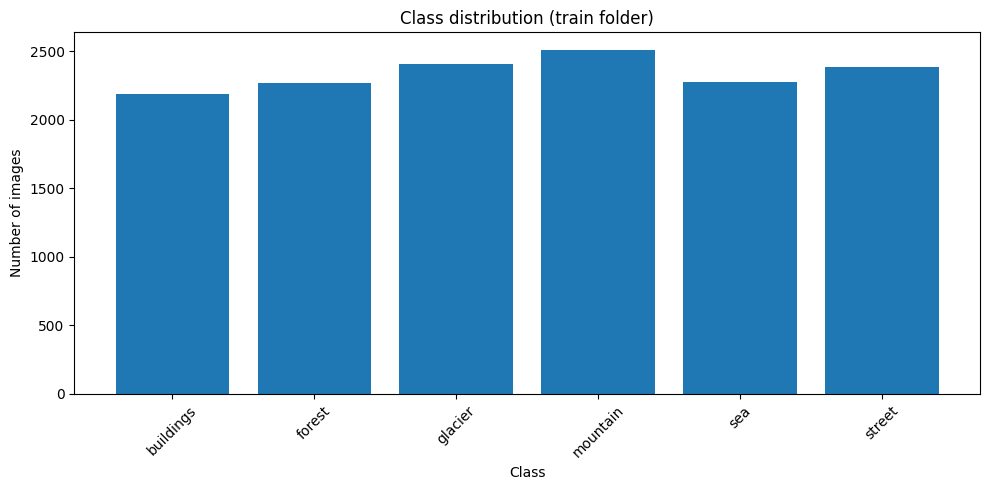

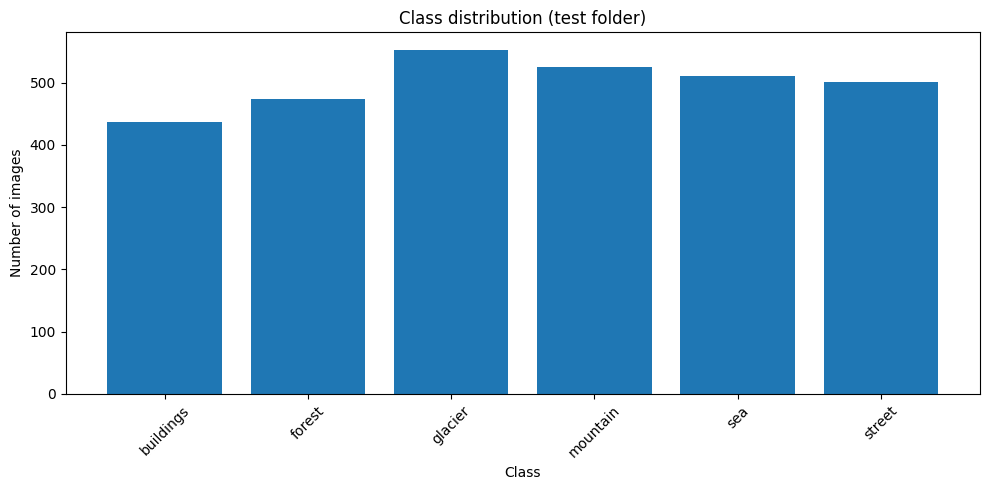

In [28]:
class_counts = Counter()
for _, label in full_dataset.samples:
    class_counts[label] += 1


counts_df = pd.DataFrame({
    "class_index": list(class_counts.keys()),
    "count": [class_counts[i] for i in sorted(class_counts.keys())]
})
counts_df['class_name'] = [full_dataset.classes[i] for i in counts_df['class_index']]
counts_df = counts_df.sort_values("class_index").reset_index(drop=True)

print(counts_df)

plt.figure(figsize=(10,5))
plt.bar(counts_df['class_name'], counts_df['count'])
plt.title("Class distribution (train folder)")
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.xticks(rotation=45)
plt.tight_layout()

if test_loader:
    test_counts = Counter([label for _, label in test_dataset.samples])
    test_df = pd.DataFrame({
        "class_name": [test_dataset.classes[i] for i in sorted(test_counts.keys())],
        "count": [test_counts[i] for i in sorted(test_counts.keys())]
    })
    plt.figure(figsize=(10,5))
    plt.bar(test_df['class_name'], test_df['count'])
    plt.title("Class distribution (test folder)")
    plt.ylabel("Number of images")
    plt.xlabel("Class")
    plt.xticks(rotation=45)
    plt.tight_layout()

print("\nIntermediate conclusions:")
print("- Total classes:", NUM_CLASSES)
print("- Largest class count:", counts_df['count'].max())
print("- Smallest class count:", counts_df['count'].min())
imbalance_ratio = counts_df['count'].max() / counts_df['count'].min() if counts_df['count'].min()>0 else float('inf')
print(f"- Imbalance ratio (max/min): {imbalance_ratio:.2f}")


In [29]:
train_augmentations = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02), 
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print("Augmentations configured.")
print("""
- RandomResizedCrop: simulates different object scales and camera zoom.
- RandomHorizontalFlip / RandomRotation: adds geometric variation so model doesn't overfit to fixed orientations.
- ColorJitter: simulates different lighting and sensor conditions.
These help improve generalization to unseen real-world scenes.
""")


train_ds.dataset.transform = train_augmentations
val_ds.dataset.transform = val_transforms
if test_loader:
    test_dataset.transform = val_transforms

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
if test_loader:
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


Augmentations configured.

- RandomResizedCrop: simulates different object scales and camera zoom.
- RandomHorizontalFlip / RandomRotation: adds geometric variation so model doesn't overfit to fixed orientations.
- ColorJitter: simulates different lighting and sensor conditions.
These help improve generalization to unseen real-world scenes.



In [ ]:
def get_model(model_name="resnet18", num_classes=NUM_CLASSES, pretrained=True):
    if model_name == "resnet18":
        model = models.resnet18(pretrained=pretrained)
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes)
    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(pretrained=pretrained)
        in_f = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_f, num_classes)
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(pretrained=pretrained)
        in_f = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_f, num_classes)
    else:
        raise ValueError(f"Unknown model_name {model_name}")
    return model


def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += images.size(0)
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def eval_model(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_targets = []
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += images.size(0)
            all_targets.extend(targets.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
    epoch_loss = running_loss / total if total>0 else 0.0
    epoch_acc = correct / total if total>0 else 0.0
    return epoch_loss, epoch_acc, np.array(all_targets), np.array(all_preds), np.array(all_probs)

model_name = "resnet18"   # "mobilenet_v2" "efficientnet_b0"
model = get_model(model_name=model_name, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

NUM_EPOCHS = 10

history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
best_val_acc = 0.0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _, _ = eval_model(model, val_loader, criterion)
    scheduler.step()
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  train_loss={train_loss:.4f} train_acc={train_acc:.4f}  val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k:v.cpu() for k,v in model.state_dict().items()} 

print("Training finished. Best val acc:", best_val_acc)

# Plot simple learning curves
plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend(); plt.title("Loss curves")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend(); plt.title("Accuracy curves")
plt.show()
